# 03 — Exploratory Data Analysis (EDA)

Explores the cleaned INMET dataset to understand distributions, 
seasonal patterns, correlations, and anomalies across the 5 cities.

All analysis reads from `data/processed/inmet_clean.parquet`.
No data is modified here.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from pathlib import Path

ROOT = Path().resolve()
PROCESSED = ROOT / "data" / "processed"

# Load the cleaned dataset
df = pd.read_parquet(PROCESSED / "inmet_clean.parquet")

print(f"Shape: {df.shape}")
print(f"Cities: {sorted(df['city'].unique())}")
print(f"Period: {df['timestamp'].min()} → {df['timestamp'].max()}")

Shape: (266592, 25)
Cities: ['Belo Horizonte', 'Brasília', 'Manaus', 'Porto Alegre', 'São Paulo']
Period: 2022-01-01 00:00:00+00:00 → 2025-12-31 23:00:00+00:00


In [2]:
# Pre-aggregate to daily and monthly city-level averages
# This is more meaningful than hourly for most analytical questions
# and much faster to plot

# We group by city + date (not station) — multiple stations per city
# are averaged together, which is exactly what we want for city-level analysis

# Daily aggregation
df["date"] = df["timestamp"].dt.date  # extract date component

df_daily = (
    df.groupby(["city", "date"])
    .agg(
        temp_c=("temp_c", "mean"),
        humidity_pct=("humidity_pct", "mean"),
        precip_mm=("precip_mm", "sum"),       # precipitation is summed, not averaged
        wind_speed_ms=("wind_speed_ms", "mean"),
        wind_gust_ms=("wind_gust_ms", "mean"),
        pressure_mb=("pressure_mb", "mean"),
        radiation_kjm2=("radiation_kjm2", "mean"),
    )
    .reset_index()
)

# Convert date back to datetime for easier plotting
df_daily["date"] = pd.to_datetime(df_daily["date"])

# Monthly aggregation — built from daily to avoid double-counting
df_daily["year_month"] = df_daily["date"].dt.to_period("M")

df_monthly = (
    df_daily.groupby(["city", "year_month"])
    .agg(
        temp_c=("temp_c", "mean"),
        humidity_pct=("humidity_pct", "mean"),
        precip_mm=("precip_mm", "sum"),
        wind_speed_ms=("wind_speed_ms", "mean"),
        pressure_mb=("pressure_mb", "mean"),
    )
    .reset_index()
)

print(f"Daily rows: {len(df_daily):,}")
print(f"Monthly rows: {len(df_monthly):,}")
print(f"\nSample daily (first 3 rows):")
print(df_daily.head(3).to_string(index=False))

Daily rows: 7,305
Monthly rows: 240

Sample daily (first 3 rows):
          city       date    temp_c  humidity_pct  precip_mm  wind_speed_ms  wind_gust_ms  pressure_mb  radiation_kjm2 year_month
Belo Horizonte 2022-01-01 19.270833     89.250000       86.0       2.031250      5.487500   897.564583      361.100466    2022-01
Belo Horizonte 2022-01-02 20.429167     84.541667       24.6       2.385417      5.650000   898.660417      763.572409    2022-01
Belo Horizonte 2022-01-03 20.768750     85.458333       45.0       2.295833      5.229167   898.389583      618.819335    2022-01


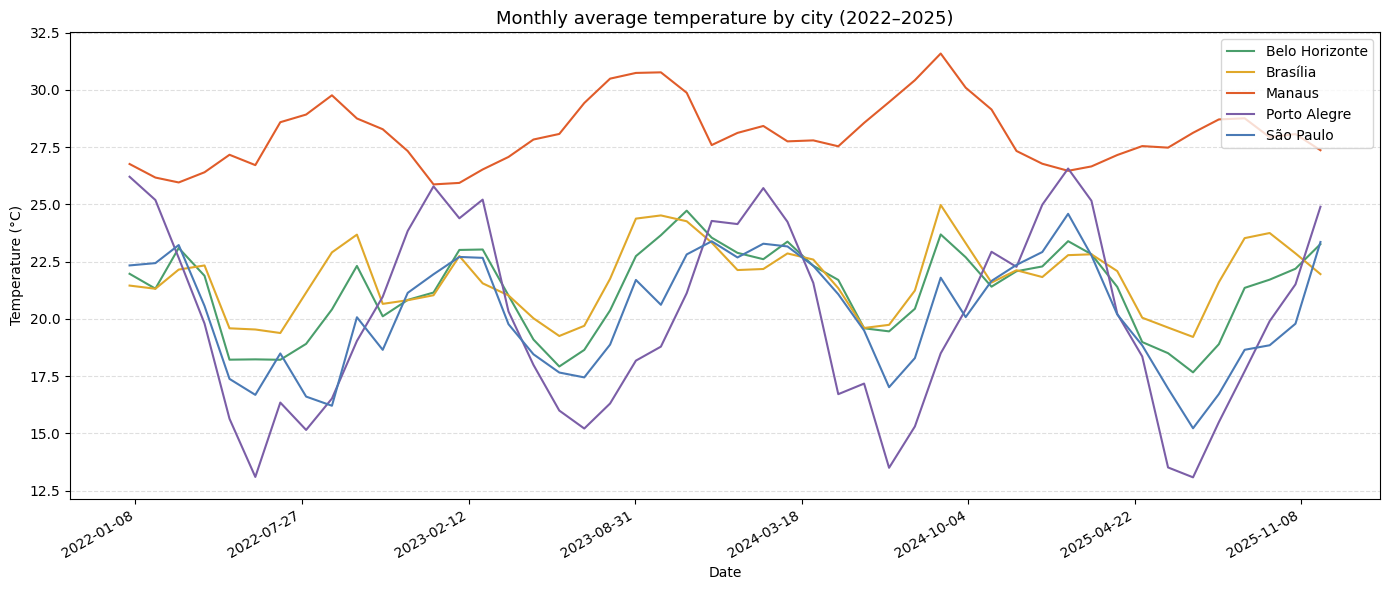

In [3]:
# Question: How does temperature evolve over time across cities?
# We use monthly averages to smooth out day-to-day noise while preserving the
# seasonal signal

# Convert Period to timestamp for plotting
df_monthly["date"] = df_monthly["year_month"].dt.to_timestamp()

# Define a consistent color per city — we'll reuse these across all plots
city_colors = {
    "Manaus": "#e05c2a",           # warm orange — hottest city
    "Brasília": "#e0a82a",         # amber — cerrado climate
    "Belo Horizonte": "#4a9e6b",   # green — mild highland
    "São Paulo": "#4a7ab5",        # blue — coastal highland
    "Porto Alegre": "#7b5ea7",     # purple — southernmost, coolest
}

fig, ax = plt.subplots(figsize=(14, 6))

for city, group in df_monthly.groupby("city"):
    ax.plot(
        group["date"],
        group["temp_c"],
        label=city,
        color=city_colors[city],
        linewidth=1.5,
    )

ax.set_title("Monthly average temperature by city (2022–2025)", fontsize=13)
ax.set_xlabel("Date")
ax.set_ylabel("Temperature (°C)")
ax.legend(loc="upper right")
ax.grid(axis="y", linestyle="--", alpha=0.4)

# Format x-axis to show year labels cleanly
ax.xaxis.set_major_locator(ticker.MaxNLocator(10))
fig.autofmt_xdate()

plt.tight_layout()
plt.show()

## Finding 1 — Temperature seasonality confirmed

- Manaus is consistently the hottest city (27–32°C), with low seasonal variation — consistent with equatorial climate
- Porto Alegre shows the largest seasonal swing (~12°C range), dropping to ~13°C in winter months
- Brasília shows similar summer highs to BH and São Paulo but warmer winter lows — the cerrado's dry season maintains higher baseline temperatures year-round
- BH and São Paulo track closely together, with slightly deeper winter dips than Brasília
- **2024 anomaly**: Manaus shows elevated temperatures in Aug–Oct 2024 compared to prior years — warrants investigation against fire hotspot data

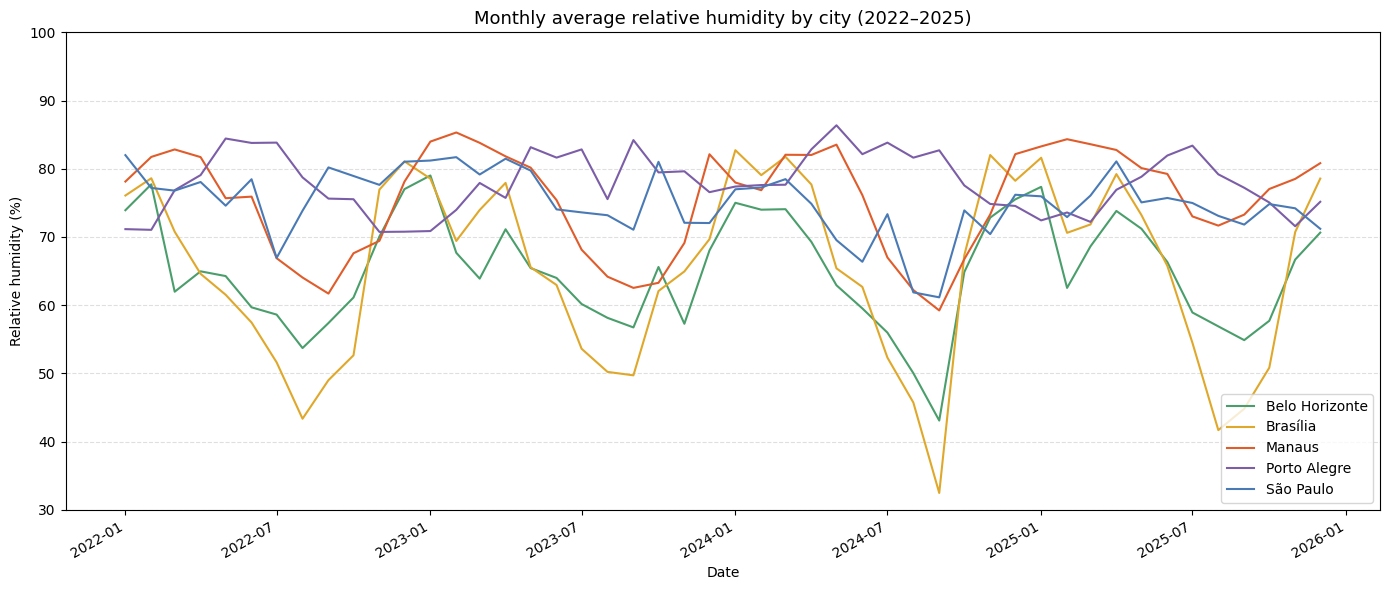

In [4]:
# Question: How does humidity vary across cities and seasons?
# We expect Manaus to be consistently high, others to dip in winter/dry season

# figsize=(14, 6) sets the figure width and height in inches
# wider than tall works well for time series — gives the x-axis room to breathe
fig, ax = plt.subplots(figsize=(14, 6))

# Loop through each city and plot its monthly humidity line
# groupby("city") splits df_monthly into one group per city
# each iteration gives us the city name and its subset of rows
for city, group in df_monthly.groupby("city"):
    ax.plot(
        group["date"],          # x-axis: time
        group["humidity_pct"],  # y-axis: humidity
        label=city,             # used by ax.legend() to label each line
        color=city_colors[city],# consistent colors we defined earlier
        linewidth=1.5,          # slightly thicker than default for readability
    )

# Chart labels and title
ax.set_title("Monthly average relative humidity by city (2022–2025)", fontsize=13)
ax.set_xlabel("Date")
ax.set_ylabel("Relative humidity (%)")

# loc="lower right" places the legend where there's likely empty space
ax.legend(loc="lower right")

# Horizontal dashed grid lines only — vertical ones add clutter on time series
ax.grid(axis="y", linestyle="--", alpha=0.4)  # alpha controls transparency

# Zoom y-axis into the meaningful range — humidity is 0-100 but
# values below 40% are rare in Brazilian cities, so this gives better resolution
ax.set_ylim(30, 100)

# Rotates and aligns x-axis date labels to avoid overlap
fig.autofmt_xdate()

# Adjusts spacing so nothing gets clipped at the edges
plt.tight_layout()

plt.show()

## Finding 2 — Humidity patterns reveal distinct climate regimes

- Brasília shows the most extreme dry season, dropping to ~32% in mid-2024 — exceptionally low even by cerrado standards
- BH follows a similar but less extreme dry season pattern (~55–60% minimum)
- Porto Alegre is consistently humid year-round (70–85%), confirming year-round frontal rainfall with no true dry season
- São Paulo behaves similarly to Porto Alegre despite being inland — Atlantic Ocean influence via Serra do Mar maintains year-round humidity
- Manaus has a real but compressed dry season (Jun–Aug), dropping ~20pp from wet season peaks — less stable than expected
- **2024 stands out again**: Brasília's record-low humidity combined with elevated Manaus temperatures suggests an unusually severe dry season nationally — strong candidate for fire hotspot correlation

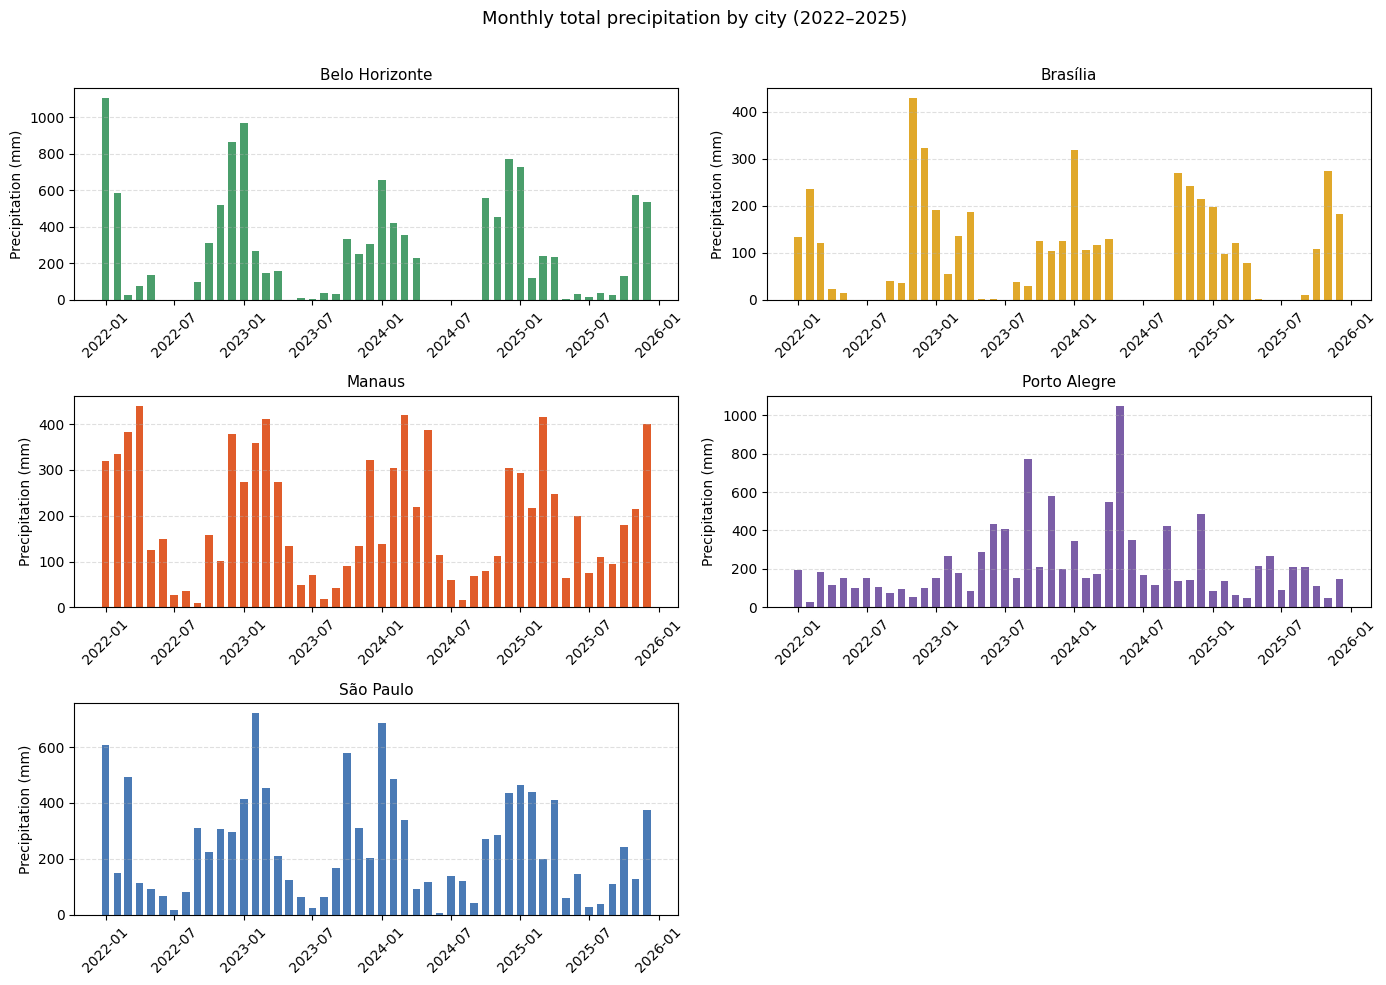

In [5]:
# Question: How does precipitation vary across cities and seasons?
# Precipitation is summed (not averaged) — we want total rainfall per month
# Bar charts are appropriate here because we're showing cumulative amounts
# not a continuous measurement like temperature

# Sorted list of cities — ensures consistent order across the grid
cities = sorted(df_monthly["city"].unique())

# 3 rows × 2 cols gives us 6 slots for 5 cities — one slot left empty
# figsize height increased to give each subplot more vertical room
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 10))

for i, city in enumerate(cities):
    # Convert flat index i into 2D grid position
    # i // 2 gives the row: 0,0,1,1,2,2
    # i % 2 gives the column: 0,1,0,1,0,1
    row = i // 2
    col = i % 2
    ax = axes[row, col]  # select the correct subplot

    # Filter monthly data for this city only
    group = df_monthly[df_monthly["city"] == city]

    ax.bar(
        group["date"],       # x-axis: monthly datetime
        group["precip_mm"],  # y-axis: total precipitation in mm
        color=city_colors[city],
        width=20,            # bar width in days — necessary because x-axis
                             # is datetime, not categorical
    )

    # Individual subplot title and axis labels
    ax.set_title(city, fontsize=11)
    ax.set_ylabel("Precipitation (mm)")

    # Horizontal grid lines only — vertical ones add clutter on bar charts
    ax.grid(axis="y", linestyle="--", alpha=0.4)

    # Rotate x-axis labels to avoid overlap between month labels
    ax.tick_params(axis="x", rotation=45)

# Hide the 6th subplot — we only have 5 cities
axes[2, 1].set_visible(False)

# Overall title sitting above all subplots
fig.suptitle("Monthly total precipitation by city (2022–2025)", fontsize=13)

# tight_layout adjusts spacing between subplots to avoid overlap
# rect leaves room at the top for the suptitle
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## Finding 3 — Precipitation confirms distinct climate regimes and flags anomalies

- BH shows the highest monthly peaks (~1000mm) driven by intense summer convective storms
- Brasília has the sharpest wet/dry contrast — near-zero rain for 4–5 months, intense wet season
- São Paulo is more seasonal than its humidity suggested — winter stays humid but rainfall drops sharply
- Manaus dry season (Jun–Aug) is clearly visible and deeper in 2024 than prior years
- Porto Alegre shows chaotic year-round rainfall driven by unpredictable frontal systems, not seasonal convection
- **2024 Manaus dry season anomaly reinforced** — deeper precipitation trough aligns with elevated temperatures and record-low humidity seen in previous charts
- **Porto Alegre spike (~1000mm)** — likely a major flood event, worth cross-referencing with historical records

### Intermediate version — precipitation bars only

First pass at the precipitation chart before adding temperature and humidity overlays. Kept to document the iterative process.

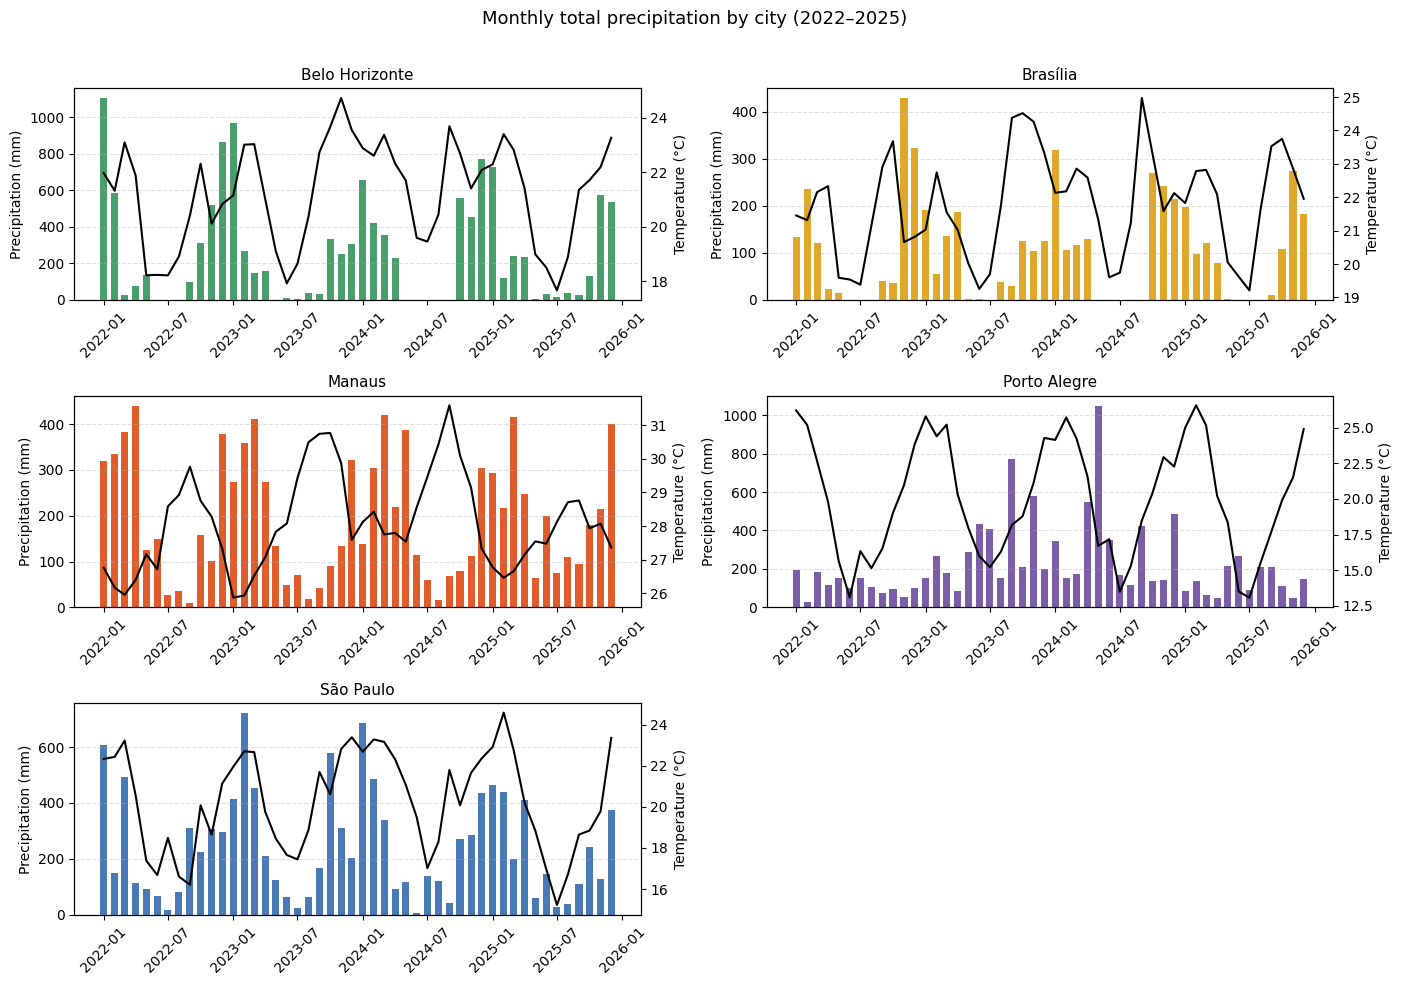

In [6]:
# Question: How does precipitation vary across cities and seasons?
# Precipitation is summed (not averaged) — we want total rainfall per month
# Bar charts are appropriate here because we're showing cumulative amounts
# not a continuous measurement like temperature

# Sorted list of cities — ensures consistent order across the grid
cities = sorted(df_monthly["city"].unique())

# 3 rows × 2 cols gives us 6 slots for 5 cities — one slot left empty
# figsize height increased to give each subplot more vertical room
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 10))

for i, city in enumerate(cities):
    # Convert flat index i into 2D grid position
    # i // 2 gives the row: 0,0,1,1,2,2
    # i % 2 gives the column: 0,1,0,1,0,1
    row = i // 2
    col = i % 2
    ax = axes[row, col]  # select the correct subplot
    ax2 = ax.twinx()

    # Filter monthly data for this city only
    group = df_monthly[df_monthly["city"] == city]

    ax.bar(
        group["date"],       # x-axis: monthly datetime
        group["precip_mm"],  # y-axis: total precipitation in mm
        color=city_colors[city],
        width=20,            # bar width in days — necessary because x-axis
                             # is datetime, not categorical
    )

    ax2.plot(
        group["date"],
        group["temp_c"],
        color="black",
        linewidth=1.5
    )

    # Individual subplot title and axis labels
    ax.set_title(city, fontsize=11)
    ax.set_ylabel("Precipitation (mm)")
    ax2.set_ylabel("Temperature (°C)")

    # Horizontal grid lines only — vertical ones add clutter on bar charts
    ax.grid(axis="y", linestyle="--", alpha=0.4)

    # Rotate x-axis labels to avoid overlap between month labels
    ax.tick_params(axis="x", rotation=45)

# Hide the 6th subplot — we only have 5 cities
axes[2, 1].set_visible(False)

# Overall title sitting above all subplots
fig.suptitle("Monthly total precipitation by city (2022–2025)", fontsize=13)

# tight_layout adjusts spacing between subplots to avoid overlap
# rect leaves room at the top for the suptitle
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## Finding 4 — Temperature-precipitation relationship differs by climate regime

- BH, São Paulo, and Brasília all show positive correlation: temperature and rainfall peak together in summer — classic tropical/subtropical convective pattern where heat drives rainfall
- Manaus shows inverse correlation: peak rainfall coincides with lower temperatures — Amazonian cloud cover during wet season blocks solar radiation and cools the surface
- Porto Alegre is the outlier in both dimensions: rainfall shows no alignment with temperature (frontal system driven), and temperature has the largest seasonal swing of all five cities due to polar air mass exposure
- This means temperature is not a universal predictor of rainfall across cities — models will need to account for city-specific climate regimes

### Final version — precipitation with temperature and humidity overlays

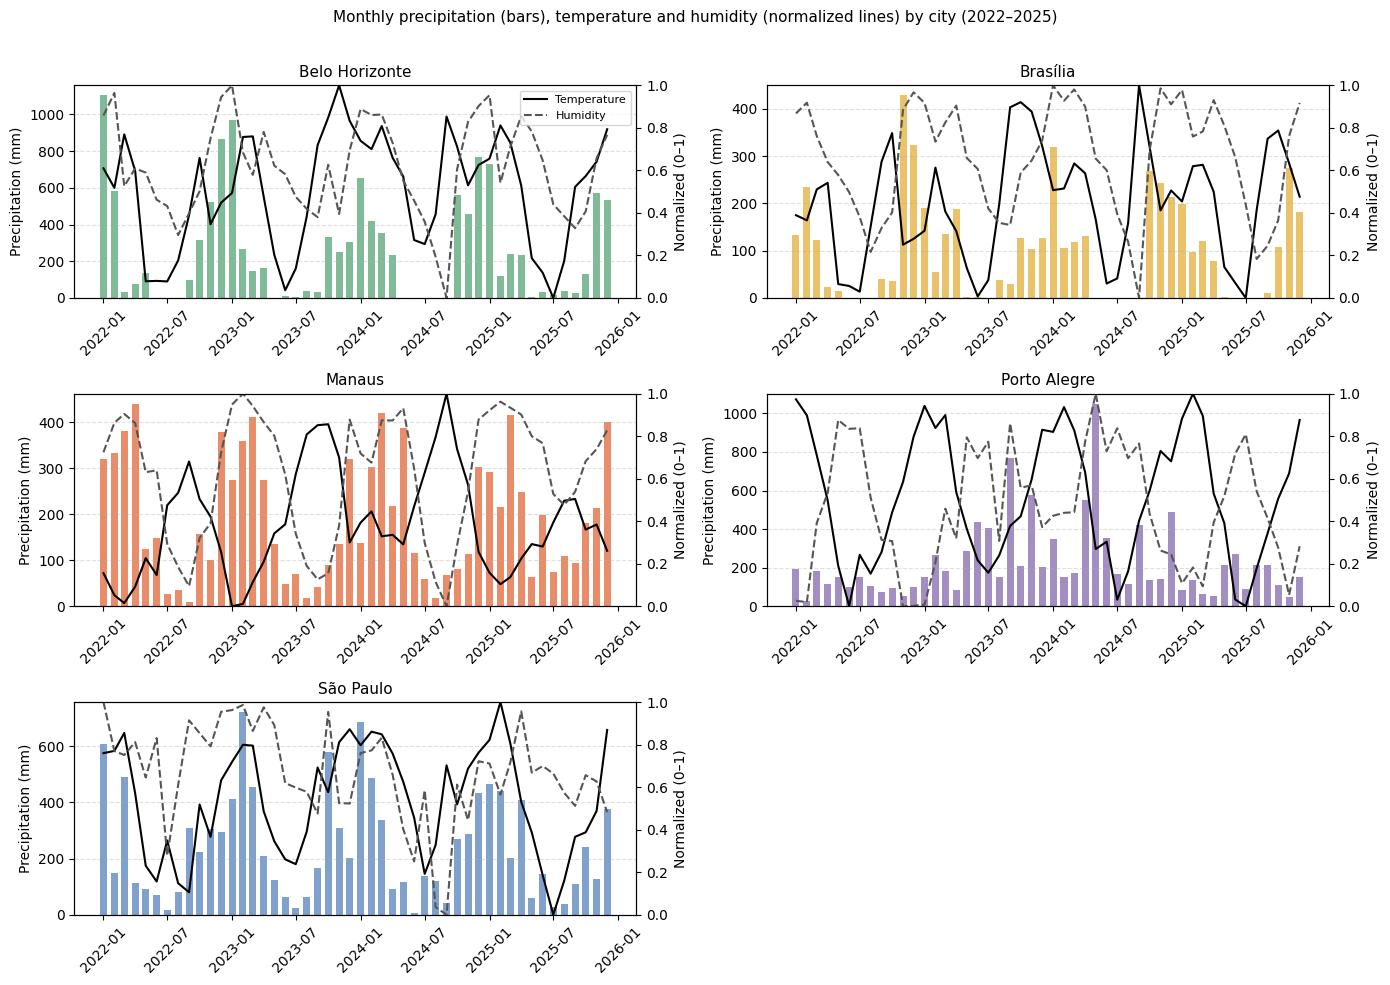

In [7]:
# Question: How do precipitation, temperature and humidity relate across cities?
# Bars show total monthly precipitation (left axis)
# Two normalized lines on the right axis show temperature and humidity
# Normalization maps both to 0-1 so they share the same axis despite different units
# This lets us compare how they move relative to each other within each city

cities = sorted(df_monthly["city"].unique())

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 10))

for i, city in enumerate(cities):
    # Convert flat index to 2D grid position
    row = i // 2
    col = i % 2
    ax = axes[row, col]

    # Filter monthly data for this city
    group = df_monthly[df_monthly["city"] == city].copy()

    # Normalize temperature and humidity to 0-1 scale
    # Formula: (value - min) / (max - min)
    # This maps the lowest value to 0 and the highest to 1
    # allowing both variables to share the same right y-axis
    group["temp_norm"] = (
        (group["temp_c"] - group["temp_c"].min()) /
        (group["temp_c"].max() - group["temp_c"].min())
    )
    group["humidity_norm"] = (
        (group["humidity_pct"] - group["humidity_pct"].min()) /
        (group["humidity_pct"].max() - group["humidity_pct"].min())
    )

    # Precipitation bars on the left axis
    ax.bar(
        group["date"],
        group["precip_mm"],
        color=city_colors[city],
        width=20,       # bar width in days — needed for datetime x-axis
        alpha=0.7,      # slight transparency so lines are visible over bars
    )

    # Create right y-axis sharing the same x-axis
    ax2 = ax.twinx()

    # Temperature line — solid black
    ax2.plot(
        group["date"],
        group["temp_norm"],
        color="black",
        linewidth=1.5,
        linestyle="-",
        label="Temperature",
    )

    # Humidity line — dashed dark gray
    ax2.plot(
        group["date"],
        group["humidity_norm"],
        color="#555555",
        linewidth=1.5,
        linestyle="--",
        label="Humidity",
    )

    # Fix right axis to 0-1 to match normalization
    ax2.set_ylim(0, 1)
    ax2.set_ylabel("Normalized (0–1)")

    # Add legend only to first subplot to avoid repetition
    # all subplots use the same line styles so one legend is enough
    if i == 0:
        ax2.legend(loc="upper right", fontsize=8)

    # Left axis label and grid
    ax.set_title(city, fontsize=11)
    ax.set_ylabel("Precipitation (mm)")
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.tick_params(axis="x", rotation=45)

# Hide the 6th empty subplot
axes[2, 1].set_visible(False)

fig.suptitle(
    "Monthly precipitation (bars), temperature and humidity (normalized lines) by city (2022–2025)",
    fontsize=11
)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## Finding 5 — Manaus temperature-precipitation relationship suggests atmospheric feedback loop

- Unlike BH, SP, and Brasília where temperature and rainfall peak together, Manaus shows temperature peaking *before* rainfall — suggesting temperature is not driven by season but by a feedback mechanism
- Hypothesis: dry season heat drives evapotranspiration → atmospheric moisture builds → cloud cover develops → radiation drops → wet season begins → rainfall cools surface
- If correct, solar radiation should be inversely correlated with humidity, and both should lead precipitation peaks
- Radiation data added to test this hypothesis directly

In [8]:
# Build Manaus monthly radiation separately from hourly data
# We excluded radiation from df_monthly earlier due to nighttime nulls
# For this chart we compute it on the fly, using mean of daytime readings only
# We filter radiation > 0 to exclude nighttime nulls before averaging

manaus_radiation = (
    df[
        (df["city"] == "Manaus") &
        (df["radiation_kjm2"] > 0)  # daytime only — exclude nighttime nulls
    ]
    .groupby(df["timestamp"].dt.to_period("M"))["radiation_kjm2"]
    .mean()
    .reset_index()
)

manaus_radiation.columns = ["year_month", "radiation_kjm2"]
manaus_radiation["date"] = manaus_radiation["year_month"].dt.to_timestamp()

print(manaus_radiation.head(3).to_string(index=False))

year_month  radiation_kjm2       date
   2022-01      916.584444 2022-01-01
   2022-02      874.521204 2022-02-01
   2022-03      874.079812 2022-03-01


C:\Users\pbbab\AppData\Local\Temp\ipykernel_23372\3189570189.py:11: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .groupby(df["timestamp"].dt.to_period("M"))["radiation_kjm2"]


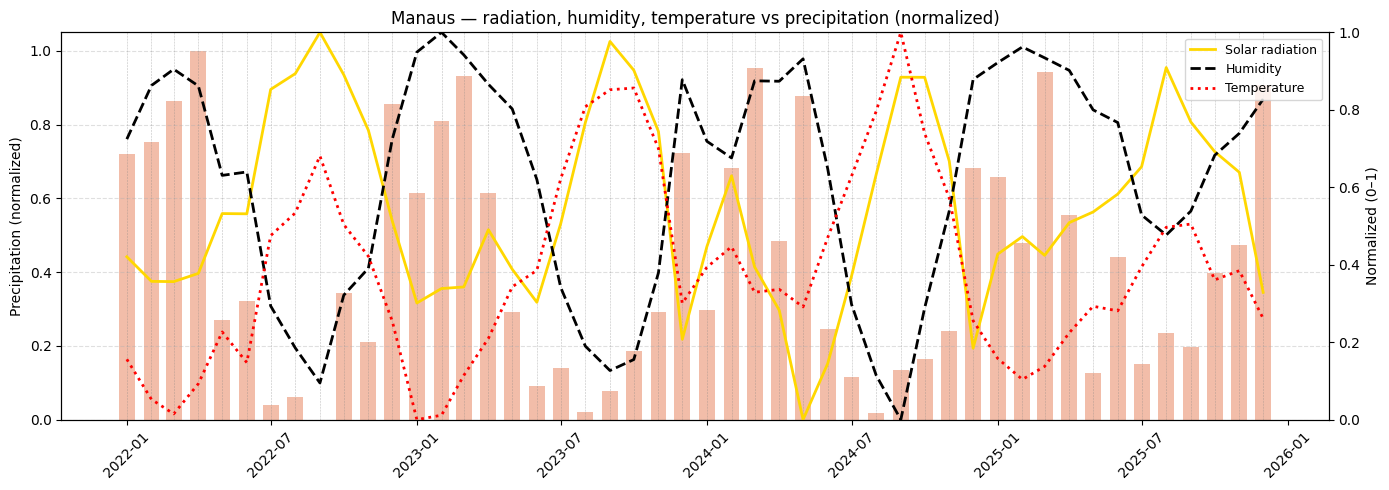

In [10]:
# Test hypothesis: radiation drops as humidity rises, preceding rainfall peak
# Using daytime-only radiation aggregated in the previous cell

# Merge radiation into manaus_monthly on year_month
manaus_plot = manaus_monthly.merge(
    manaus_radiation[["year_month", "radiation_kjm2"]],
    on="year_month",
    how="left",
)

# Normalize all variables to 0-1 for comparison on the same axis
manaus_plot["radiation_norm"] = (
    (manaus_plot["radiation_kjm2"] - manaus_plot["radiation_kjm2"].min()) /
    (manaus_plot["radiation_kjm2"].max() - manaus_plot["radiation_kjm2"].min())
)
manaus_plot["humidity_norm"] = (
    (manaus_plot["humidity_pct"] - manaus_plot["humidity_pct"].min()) /
    (manaus_plot["humidity_pct"].max() - manaus_plot["humidity_pct"].min())
)
manaus_plot["precip_norm"] = (
    (manaus_plot["precip_mm"] - manaus_plot["precip_mm"].min()) /
    (manaus_plot["precip_mm"].max() - manaus_plot["precip_mm"].min())
)
manaus_plot["temp_norm"] = (
    (manaus_plot["temp_c"] - manaus_plot["temp_c"].min()) /
    (manaus_plot["temp_c"].max() - manaus_plot["temp_c"].min())
)

fig, ax = plt.subplots(figsize=(14, 5))

# Precipitation bars for reference
ax.bar(
    manaus_plot["date"],
    manaus_plot["precip_norm"],
    color=city_colors["Manaus"],
    width=20,
    alpha=0.4,
    label="Precipitation (normalized)",
)

ax2 = ax.twinx()

# Solar radiation — gold solid line
ax2.plot(
    manaus_plot["date"],
    manaus_plot["radiation_norm"],
    color="gold",
    linewidth=2,
    linestyle="-",
    label="Solar radiation",
)

# Humidity — black dashed line
ax2.plot(
    manaus_plot["date"],
    manaus_plot["humidity_norm"],
    color="black",
    linewidth=2,
    linestyle="--",
    label="Humidity",
)

# Temperature — red dotted line
ax2.plot(
    manaus_plot["date"],
    manaus_plot["temp_norm"],
    color="red",
    linewidth=2,
    linestyle=":",
    label="Temperature",
)

# Vertical reference lines aligned to each bar's date
# Makes it easier to trace where the normalized lines cross each month
for date in manaus_plot["date"]:
    ax.axvline(x=date, color="gray", linewidth=0.4, linestyle="--", alpha=0.5)

ax2.set_ylim(0, 1)
ax2.legend(loc="upper right", fontsize=9)
ax.set_ylabel("Precipitation (normalized)")
ax2.set_ylabel("Normalized (0–1)")
ax.set_title("Manaus — radiation, humidity, temperature vs precipitation (normalized)", fontsize=12)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## Finding 6 — Manaus feedback loop confirmed by radiation data

- Solar radiation and humidity are near-perfectly inverse throughout 2022–2025 — confirming cloud cover suppresses radiation as moisture builds
- Temperature closely follows radiation with a short lag — surface heating is radiation-driven, not season-driven
- Rainfall peaks consistently align with radiation troughs — wet season arrives after cloud cover has already suppressed solar input
- Full mechanism confirmed: dry season heat → evapotranspiration → cloud buildup → radiation drop → wet season onset → surface cooling
- This feedback loop is unique among the 5 cities and explains the inverse temperature-rainfall pattern seen in Finding 4

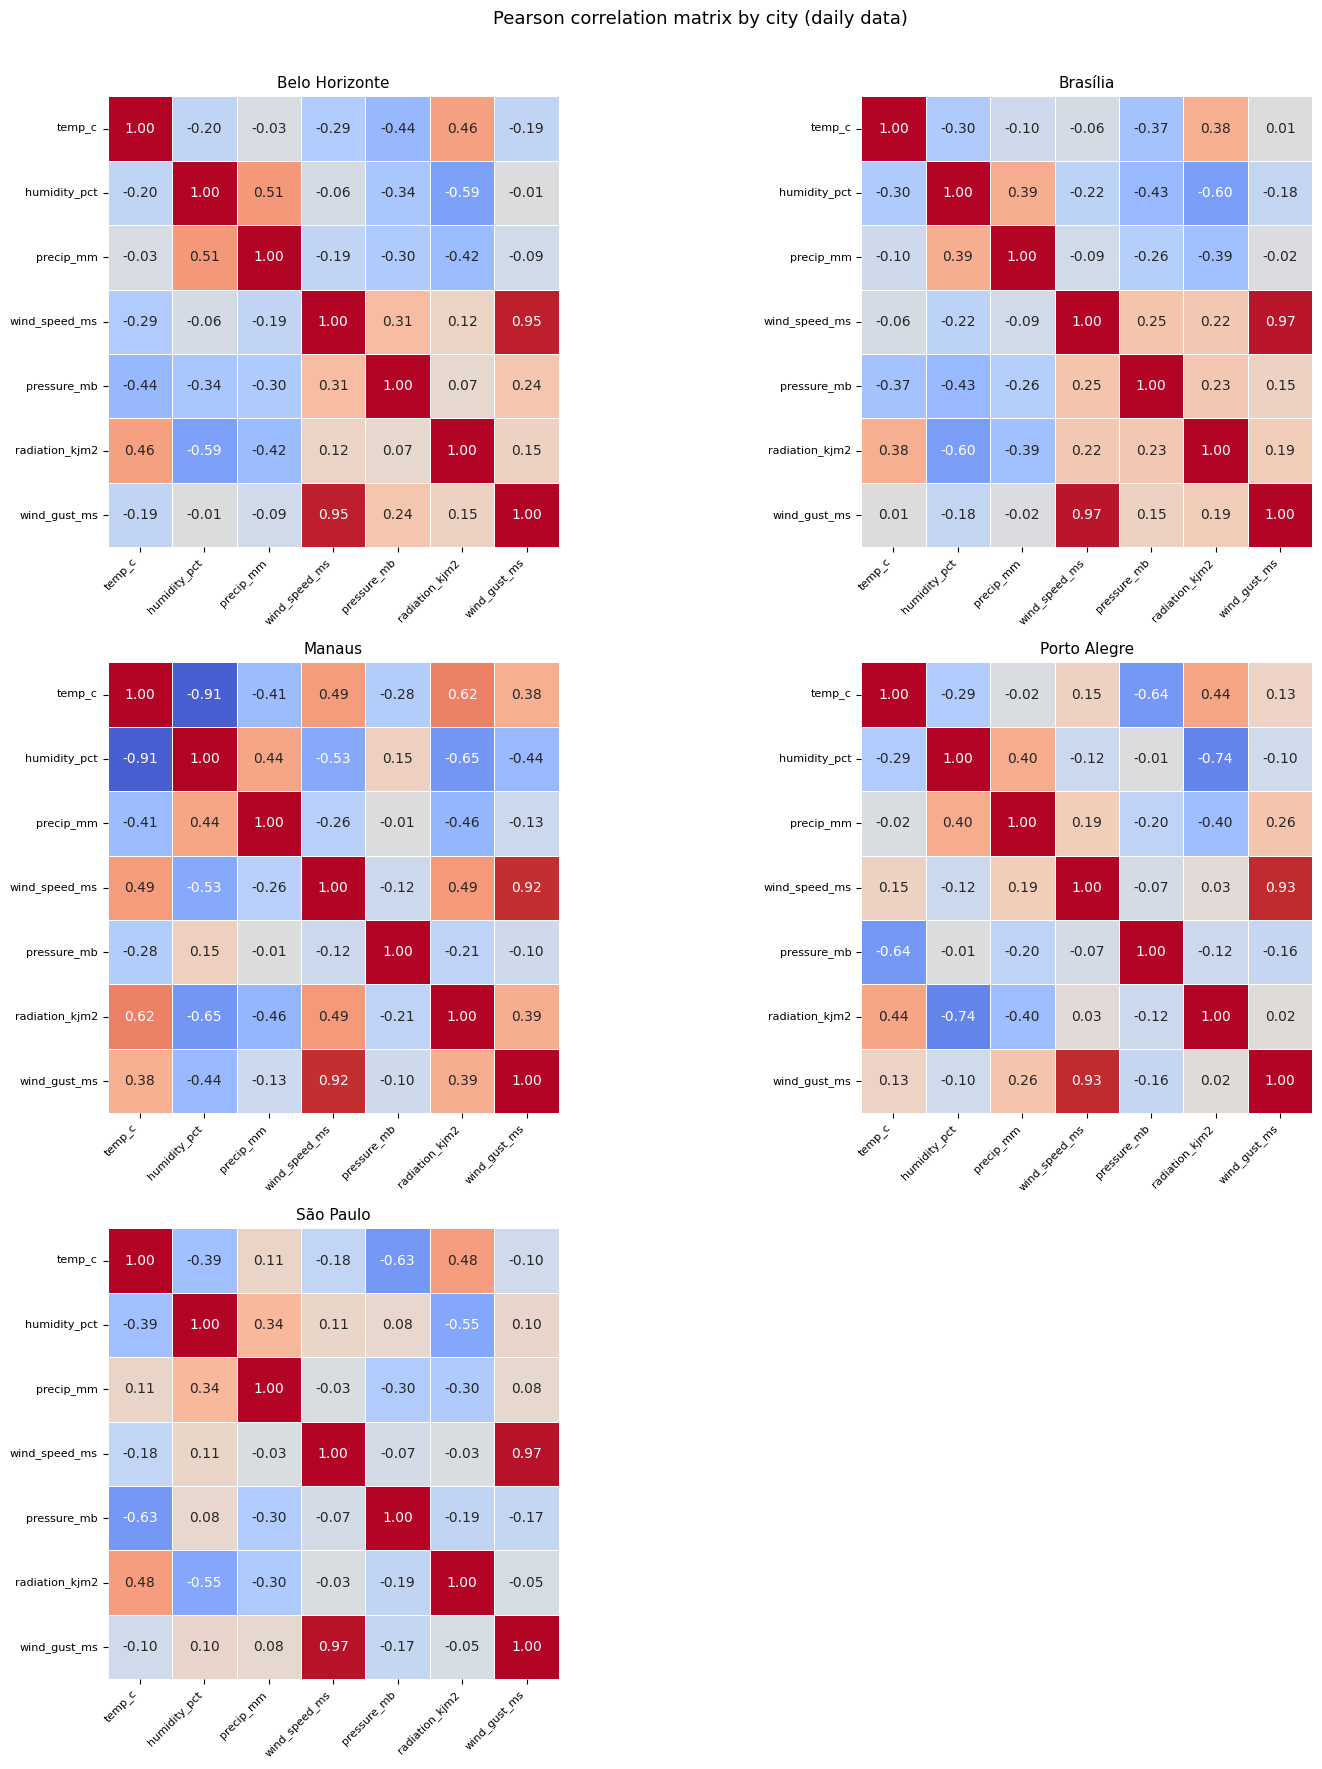

In [11]:
# Question: Which variables are most correlated with each other, per city?
# We use daily data for more reliable estimates than monthly
# Correlation ranges from -1 (perfect inverse) to 1 (perfect positive)

# Variables to include — exclude metadata and non-numeric columns
corr_cols = [
    "temp_c", "humidity_pct", "precip_mm", "wind_speed_ms",
    "pressure_mb", "radiation_kjm2", "wind_gust_ms",
]

cities = sorted(df["city"].unique())

# One heatmap per city — same grid structure as precipitation chart
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(16, 18))

for i, city in enumerate(cities):
    row = i // 2
    col = i % 2
    ax = axes[row, col]

    # Filter daily data for this city
    city_data = df_daily[df_daily["city"] == city][corr_cols]

    # Compute correlation matrix
    # method="pearson" measures linear correlation — standard starting point
    corr_matrix = city_data.corr(method="pearson")

    # Draw heatmap
    sns.heatmap(
        corr_matrix,
        ax=ax,
        annot=True,        # show correlation values inside each cell
        fmt=".2f",         # round to 2 decimal places
        cmap="coolwarm",   # blue = negative, red = positive, white = zero
        center=0,          # center the colormap at zero
        vmin=-1, vmax=1,   # fix scale to full correlation range
        square=True,       # keep cells square for readability
        linewidths=0.5,    # thin lines between cells
        cbar=False,        # skip individual colorbars — too cluttered
    )

    ax.set_title(city, fontsize=11)

    # Rotate axis labels for readability
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)

# Hide 6th empty subplot
axes[2, 1].set_visible(False)

fig.suptitle("Pearson correlation matrix by city (daily data)", fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## Finding 7 — Correlation analysis reveals universal patterns and city-specific signatures

**Universal across all cities:**
- wind_speed and wind_gust are near-perfectly correlated (0.92–0.97) — redundant variables, only one needed for modeling
- radiation and humidity are consistently negatively correlated (-0.55 to -0.74) — cloud cover effect present in all cities

**Manaus:**
- temp vs humidity at -0.91 — strongest correlation in the entire dataset and the only city where this relationship is strongly negative — quantifies the feedback loop confirmed in Finding 6

**Porto Alegre:**
- pressure vs temperature at -0.64 — cold fronts drive simultaneous temperature drops and pressure changes, unique extratropical signature

**Humidity vs precipitation (your hypothesis):**
- Moderate positive correlation across all cities (0.34–0.51) — directionally correct but weaker than expected
- High humidity is a necessary but not sufficient condition for rainfall — atmospheric moisture alone doesn't guarantee a rain event

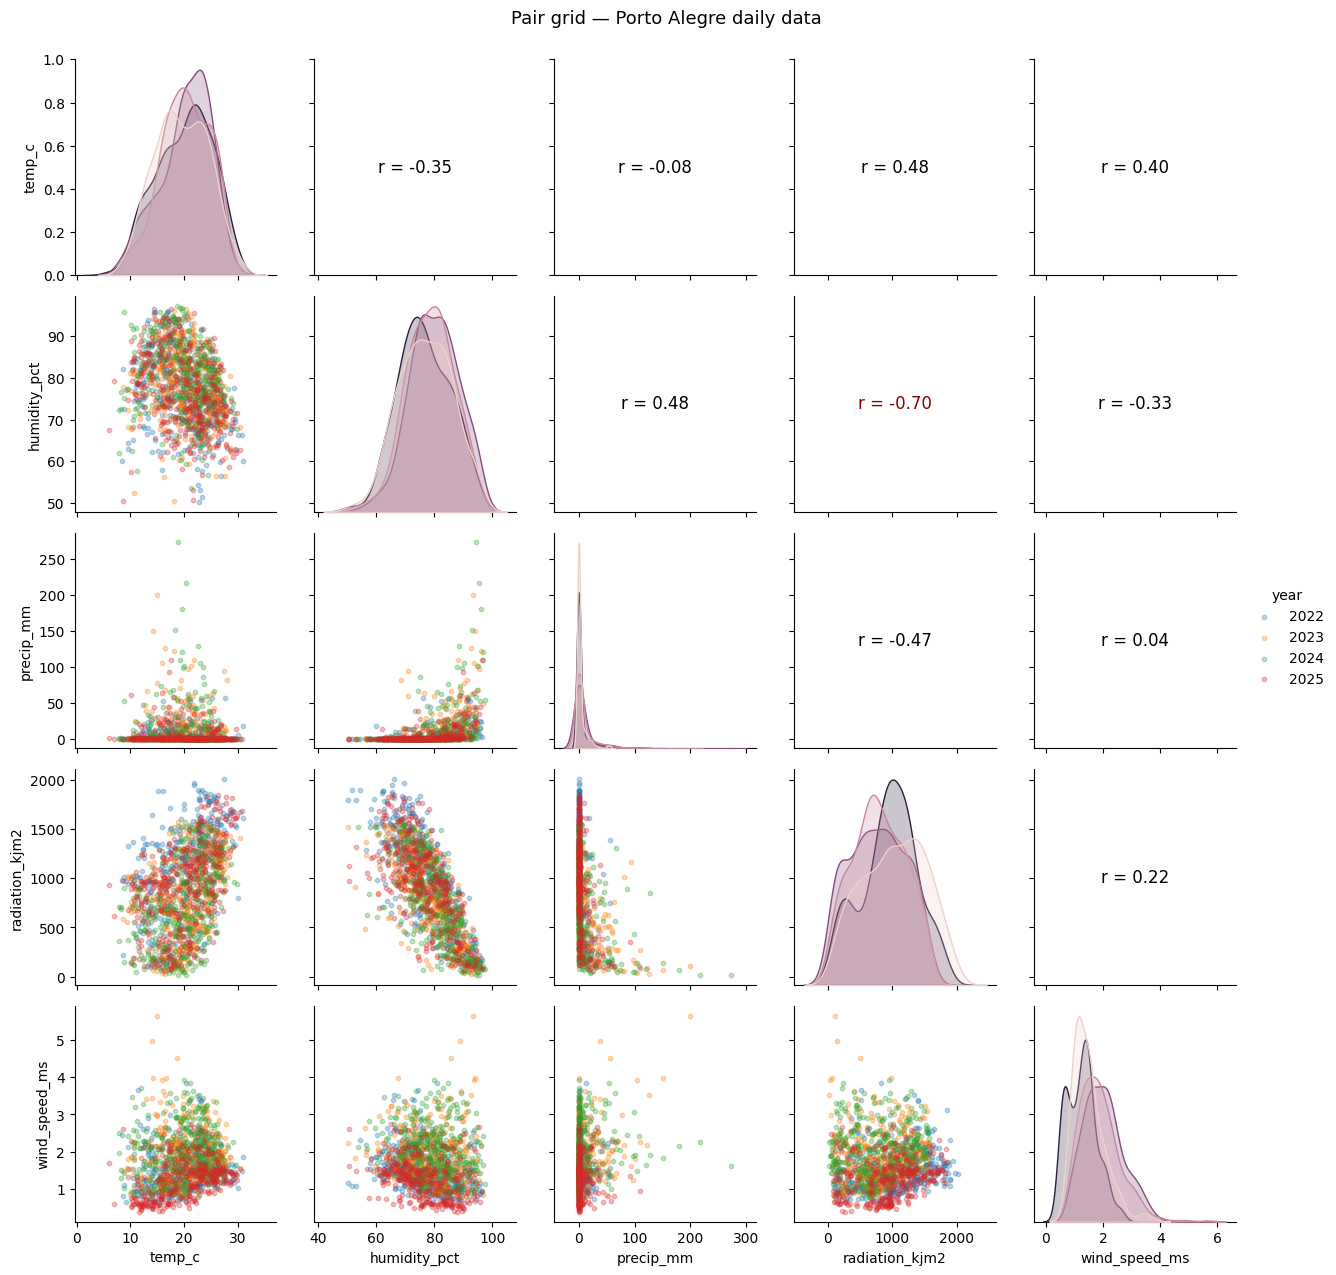

In [12]:
# PairGrid gives full control over each triangle independently
# Lower triangle: scatter plots
# Upper triangle: correlation coefficients as text
# Diagonal: KDE distributions

pa_daily = df_daily[df_daily["city"] == "Porto Alegre"][
    ["temp_c", "humidity_pct", "precip_mm", "radiation_kjm2", "wind_speed_ms"]
].copy()
pa_daily["year"] = df_daily[df_daily["city"] == "Porto Alegre"]["date"].dt.year.values

# Define a function to print correlation coefficient in the upper triangle cells
def corrfunc(x, y, **kwargs):
    # Compute correlation on all data regardless of hue (year)
    # Without this, the function is called once per year and overlaps
    r = x.corr(y)
    ax = plt.gca()
    # Clear any previous text drawn by earlier hue iterations
    for txt in ax.texts:
        txt.remove()
    ax.annotate(
        f"r = {r:.2f}",
        xy=(0.5, 0.5),
        xycoords="axes fraction",
        ha="center",
        va="center",
        fontsize=12,
        color="darkred" if abs(r) > 0.5 else "black",
    )

g = sns.PairGrid(pa_daily, hue="year", diag_sharey=False)

# Lower triangle — scatter plots
g.map_lower(plt.scatter, alpha=0.3, s=10)

# Diagonal — KDE
g.map_diag(sns.kdeplot, fill=True)

# Upper triangle — correlation coefficients
g.map_upper(corrfunc)

g.add_legend()
g.figure.suptitle("Pair grid — Porto Alegre daily data", fontsize=13, y=1.02)
plt.show()

In [13]:
# Anomaly detection using Z-scores
# Z-score measures how many standard deviations a value is from the mean
# We compute per city so each city is compared against its own baseline
# not against other cities which have very different climates

# Variables to check — the ones where we visually spotted anomalies
anomaly_vars = ["temp_c", "humidity_pct", "precip_mm"]

# Compute Z-scores per city for each variable
def add_zscores(df, variables):
    """
    Adds Z-score columns for each variable, computed per city.
    A Z-score of ±2 flags the top/bottom ~5% of observations.
    A Z-score of ±3 flags the top/bottom ~0.3% — genuinely unusual.
    """
    df = df.copy()
    for var in variables:
        # Group by city, compute mean and std, then normalize
        df[f"{var}_z"] = df.groupby("city")[var].transform(
            lambda x: (x - x.mean()) / x.std()
        )
    return df

df_monthly_z = add_zscores(df_monthly, anomaly_vars)

# Find the most anomalous months — Z-score beyond ±2.5 in any variable
z_cols = [f"{v}_z" for v in anomaly_vars]

# Create a column for the maximum absolute Z-score across all variables
df_monthly_z["max_abs_z"] = df_monthly_z[z_cols].abs().max(axis=1)

# Filter and sort by most anomalous
anomalies = (
    df_monthly_z[df_monthly_z["max_abs_z"] > 2.5]
    .sort_values("max_abs_z", ascending=False)
    .reset_index(drop=True)
    [["city", "year_month", "temp_c", "humidity_pct", "precip_mm"] + z_cols + ["max_abs_z"]]
)

print(f"Anomalous months (|Z| > 2.5): {len(anomalies)}")
print(anomalies.to_string(index=False))

Anomalous months (|Z| > 2.5): 9
          city year_month    temp_c  humidity_pct  precip_mm  temp_c_z  humidity_pct_z  precip_mm_z  max_abs_z
  Porto Alegre    2024-05 16.713815     86.369209     1049.7 -0.819660        1.929420     4.174867   4.174867
      Brasília    2022-11 20.657361     76.938889      428.4 -0.714955        0.891389     3.047381   3.047381
     São Paulo    2024-09 21.799306     61.146875       42.6  0.620509       -2.931590    -1.068927   2.931590
Belo Horizonte    2022-01 21.970228     73.920027     1102.8  0.392665        1.116424     2.883159   2.883159
     São Paulo    2024-08 18.289516     61.875000      119.0 -0.822938       -2.778238    -0.664790   2.778238
  Porto Alegre    2023-09 18.178542     84.201389      770.0 -0.458777        1.434991     2.758510   2.758510
Belo Horizonte    2024-09 23.688264     43.081944        2.0  1.307774       -2.744459    -0.873425   2.744459
     São Paulo    2023-02 22.706027     81.699033      721.6  0.993410        1.

## Finding 8 — Statistical anomaly detection confirms 2024 as the standout year

**Method:** Z-scores computed per city — measures standard deviations from each city's own baseline

**Most anomalous months (|Z| > 2.5):**

- **Porto Alegre 2024-05** — Z = +4.17 on precipitation (1049mm) — the catastrophic Rio Grande do Sul floods of May 2024, one of Brazil's worst natural disasters
- **São Paulo 2024-08/09** — Z = -2.78/-2.93 on humidity — anomalously dry winter
- **BH 2024-09** — Z = -2.74 on humidity — same drought signal
- **Brasília 2024-09** — Z = -2.51 on humidity (32.4% average) — record dry month confirmed statistically

**Central narrative:** 2024 shows two simultaneous extremes — catastrophic flooding in the south (May) and severe drought across the southeast/center-west (Aug–Sep). Both are consistent with the strong El Niño of 2024 and will be the primary focus of air quality correlation analysis when fire hotspot data is integrated.

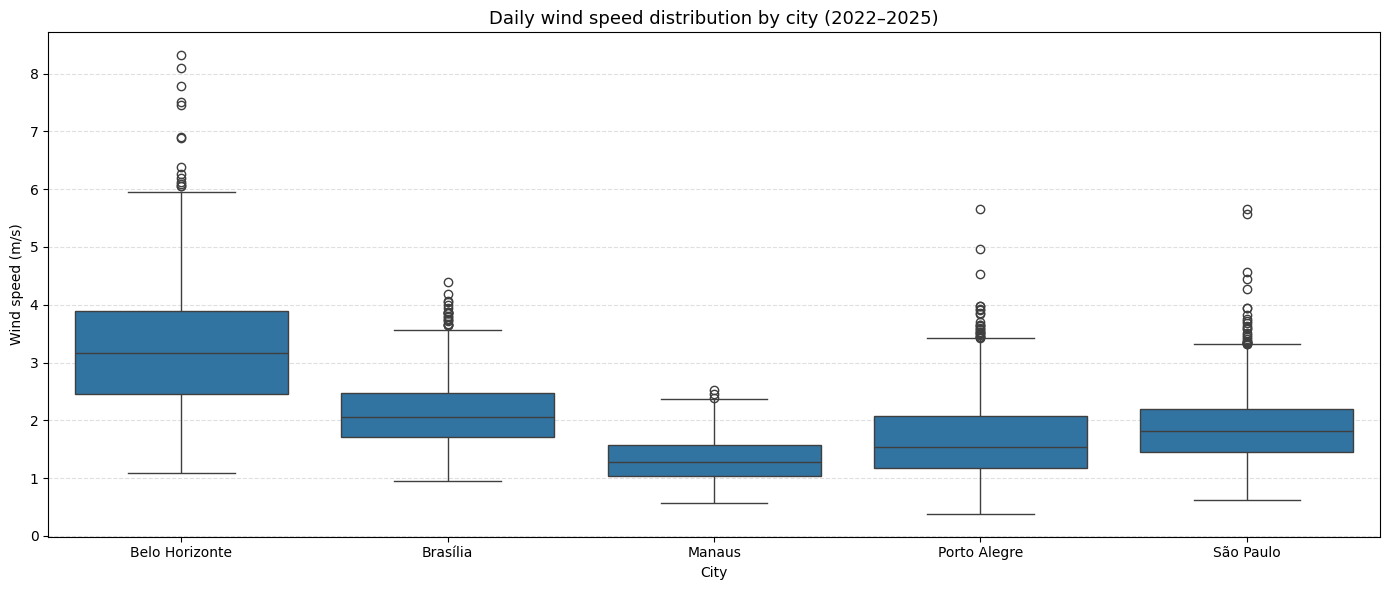

In [14]:
fig, ax = plt.subplots(figsize=(14, 6))

sns.boxplot(
    data=df_daily,
    x="city",
    y="wind_speed_ms",
    ax=ax,
)

ax.set_title("Daily wind speed distribution by city (2022–2025)", fontsize=13)
ax.set_ylabel("Wind speed (m/s)")
ax.set_xlabel("City")
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

## Finding 9 — Wind patterns reflect local geography and frontal systems

- Belo Horizonte is surprisingly the windiest city — terrain channeling through surrounding mountain ranges likely accelerates surface winds at station locations
- Manaus is the calmest as predicted — Amazon forest canopy absorbs surface wind, low-lying basin with no pressure gradient
- Porto Alegre shows the highest day-to-day variability — wide IQR reflects sudden wind events when cold fronts pass, consistent with chaotic precipitation pattern
- Brasília calmer than expected despite open plateau — possibly station positioning or low cerrado vegetation absorbing surface flow
- **Air quality implication:** Manaus's consistently calm winds mean pollutants and fire smoke have minimal natural dispersion — compounding the impact of dry season fire hotspots

[Text(1, 0, 'Jan'),
 Text(2, 0, 'Feb'),
 Text(3, 0, 'Mar'),
 Text(4, 0, 'Apr'),
 Text(5, 0, 'May'),
 Text(6, 0, 'Jun'),
 Text(7, 0, 'Jul'),
 Text(8, 0, 'Aug'),
 Text(9, 0, 'Sep'),
 Text(10, 0, 'Oct'),
 Text(11, 0, 'Nov'),
 Text(12, 0, 'Dec')]

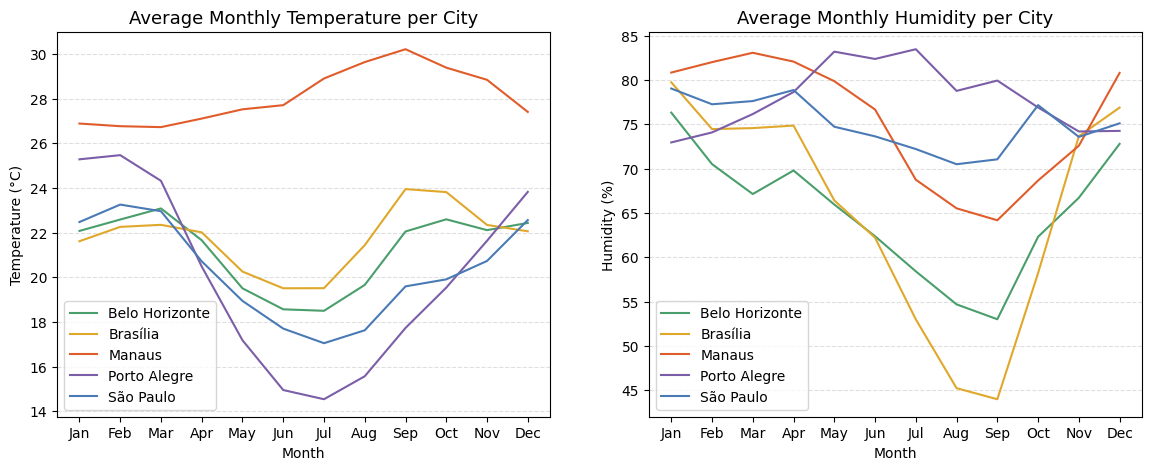

In [15]:
df_daily["month"] = df_daily["date"].dt.month

group = df_daily.groupby(["city", "month"])[["temp_c", "humidity_pct"]].mean()
group_reset = group.reset_index()

fig, axes = plt.subplots(nrows=1,ncols=2, figsize=(14, 5))

parameters = ["temp_c", "humidity_pct"]

ax1 = axes[0]

for city, data in group_reset.groupby("city"):
    ax1.plot(
        data["month"],
        data["temp_c"],
        label=city,
        color=city_colors[city]
    )

ax2 = axes[1]

for city, data in group_reset.groupby("city"):
    ax2.plot(
        data["month"],
        data["humidity_pct"],
        label=city,
        color=city_colors[city]
    )

ax1.set_title("Average Monthly Temperature per City", fontsize=13)

ax1.set_xlabel("Month")

ax1.set_ylabel("Temperature (°C)")

ax1.legend(loc="lower left")

ax1.grid(axis="y", linestyle="--", alpha=0.4)

ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun",
                      "Jul","Aug","Sep","Oct","Nov","Dec"])

ax2.set_title("Average Monthly Humidity per City", fontsize=13)

ax2.set_xlabel("Month")

ax2.set_ylabel("Humidity (%)")

ax2.legend(loc="lower left")

ax2.grid(axis="y", linestyle="--", alpha=0.4)

ax2.set_xticks(range(1, 13))
ax2.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun",
                      "Jul","Aug","Sep","Oct","Nov","Dec"])

## Finding 10 — Typical seasonal patterns confirm climate regime boundaries

- Temperature seasonality is consistent across all cities except Manaus — all show a clear winter trough (Jun–Aug), Manaus remains nearly flat year-round
- Humidity seasonality separates cities into two groups:
  - Clear dry season: BH, Brasília, Manaus, São Paulo — humidity drops significantly Jun–Sep
  - No dry season: Porto Alegre — humidity curve nearly flat year-round, confirming frontal rainfall dominates over seasonal convection
- These typical year profiles will serve as the baseline for anomaly detection when air quality data is integrated — pollution spikes during dry season months will be evaluated against this seasonal expectation

### Limitation — dataset too short for trend analysis

4 years (2022–2025) is sufficient for seasonal pattern characterization and 
anomaly detection but insufficient for identifying multi-year warming or drying 
trends. The 2024 anomaly is well-documented but cannot be distinguished from 
natural El Niño variability without a longer baseline. Extending the dataset 
to 2015–2025 using the same INMET bulk download would enable proper trend 
analysis — a natural next step for this project.